# Dashboard Spec Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/dashboard-spec/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/dashboard-spec/demo.ipynb)

> Dashboards built from vague asks. This reads the data's shape and recommends the right charts — with the reasoning.

"Build me a dashboard" with no spec ends in a pie chart of 30 categories. The fix is to let the
*data's structure* drive the chart choice: a time column wants a line, a category vs a measure wants
bars, two measures want a scatter. This turns a dataset into a recommended, justified dashboard spec.

**What this notebook covers**
1. Classifying columns into roles (temporal / categorical / measure)
2. Encoding rules that map roles → chart types
3. A full recommended dashboard spec
4. Rendering the recommended charts
5. Why role detection is the whole game


## Step 1 - Classify columns into roles

Chart choice starts with knowing what each column *is*. A date is temporal, a low-cardinality string
is categorical, a number is a measure. Everything downstream depends on this.

In [1]:
from dashspec import classify_columns, recommend_dashboard, spec_to_dict, sample_dataframe

df = sample_dataframe()
for r in classify_columns(df):
    print(f"  {r.name:<10} -> {r.role}")


  date       -> temporal
  region     -> categorical
  channel    -> categorical
  revenue    -> measure
  sessions   -> measure


## Step 2 - Roles → charts (the encoding rules)

Each recommendation is a rule from visualization best practice: temporal + measure → line;
categorical + measure → **bar, not pie**; two measures → scatter; one measure → histogram.

In [2]:
panels = recommend_dashboard(df)
for p in panels:
    enc = ", ".join(f"{k}={getattr(p, k)}" for k in ("x", "y", "series") if getattr(p, k))
    print(f"[{p.chart:<12}] {p.title}")
    print(f"    encoding: {enc}")
    print(f"    why: {p.rationale}\n")


[kpi         ] Total revenue
    encoding: y=revenue
    why: A headline number gives the dashboard an at-a-glance summary.

[kpi         ] Total sessions
    encoding: y=sessions
    why: A headline number gives the dashboard an at-a-glance summary.

[line        ] revenue over time
    encoding: x=date, y=revenue
    why: A time column + a measure is a trend - lines show change over time best.

[bar         ] revenue by region
    encoding: x=region, y=revenue
    why: A category vs a measure compares magnitudes - bars beat pies for that.

[grouped_bar ] revenue by region and channel
    encoding: x=region, y=revenue, series=channel
    why: Two dimensions over one measure - group bars by the second dimension.

[scatter     ] revenue vs sessions
    encoding: x=revenue, y=sessions
    why: Two measures invite a correlation check - scatter reveals the relationship.



## Step 3 - The spec as JSON

The output is a portable spec - hand it to any BI tool, or render it yourself. It's the artifact a
vague "build me a dashboard" was missing.

In [3]:
import json
print(json.dumps(spec_to_dict(panels)[:3], indent=2))
print("...")


[
  {
    "title": "Total revenue",
    "chart": "kpi",
    "y": "revenue",
    "agg": "sum",
    "rationale": "A headline number gives the dashboard an at-a-glance summary."
  },
  {
    "title": "Total sessions",
    "chart": "kpi",
    "y": "sessions",
    "agg": "sum",
    "rationale": "A headline number gives the dashboard an at-a-glance summary."
  },
  {
    "title": "revenue over time",
    "chart": "line",
    "x": "date",
    "y": "revenue",
    "agg": "sum",
    "rationale": "A time column + a measure is a trend - lines show change over time best."
  }
]
...


## Step 4 - Render the recommended dashboard

Proof the recommendations are usable: render four of the panels straight from the spec + data.

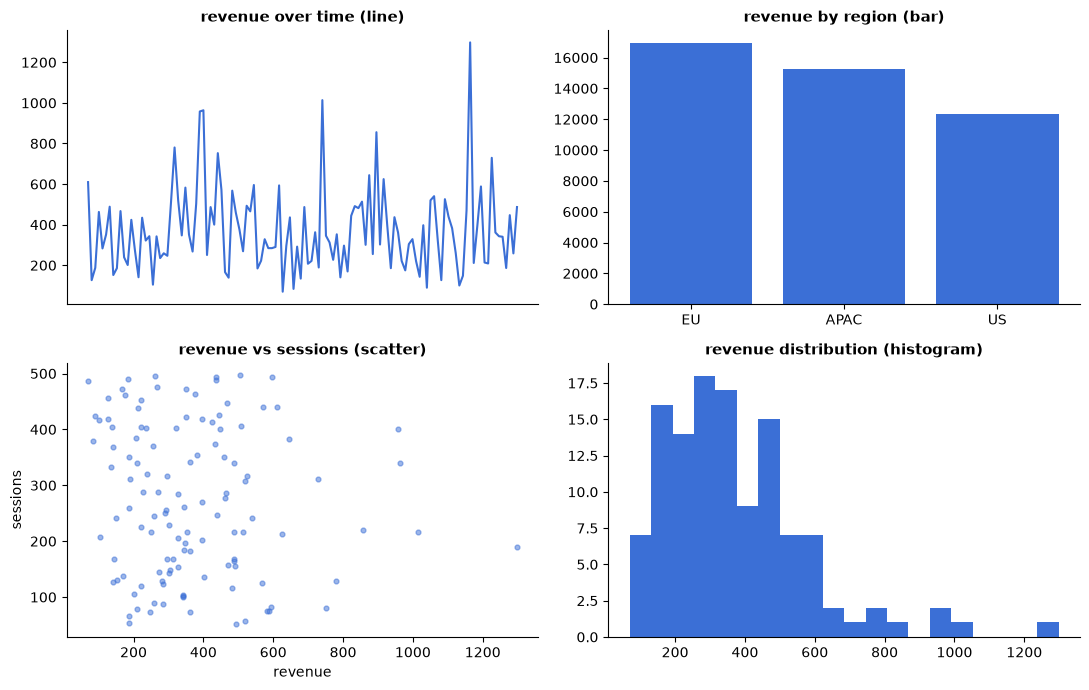

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# line: revenue over time
g = df.groupby("date")["revenue"].sum()
axes[0, 0].plot(range(len(g)), g.values, color="#3b6fd6")
axes[0, 0].set_title("revenue over time (line)", fontsize=11, weight="bold")
axes[0, 0].set_xticks([])

# bar: revenue by region
gb = df.groupby("region")["revenue"].sum().sort_values(ascending=False)
axes[0, 1].bar(gb.index, gb.values, color="#3b6fd6")
axes[0, 1].set_title("revenue by region (bar)", fontsize=11, weight="bold")

# scatter: revenue vs sessions
axes[1, 0].scatter(df["revenue"], df["sessions"], s=12, alpha=0.5, color="#3b6fd6")
axes[1, 0].set_title("revenue vs sessions (scatter)", fontsize=11, weight="bold")
axes[1, 0].set_xlabel("revenue")
axes[1, 0].set_ylabel("sessions")

# histogram: revenue distribution
axes[1, 1].hist(df["revenue"], bins=20, color="#3b6fd6")
axes[1, 1].set_title("revenue distribution (histogram)", fontsize=11, weight="bold")

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("recommended_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()


## Step 5 - Role detection is the whole game

Get the role wrong and every chart is wrong - a date read as a category becomes an unreadable bar
with 120 bars. The temporal detector checks the name *and* tries to parse values, so `date` is a
line, not a categorical axis.

In [5]:
wrong = [r for r in classify_columns(df) if r.name == "date"][0]
print(f"'date' classified as: {wrong.role}")
print("-> drives a LINE chart. Misclassified as categorical, it would be a 120-bar mess.")


'date' classified as: temporal
-> drives a LINE chart. Misclassified as categorical, it would be a 120-bar mess.


## Summary

| Data shape | Recommended chart |
|-----------|-------------------|
| temporal + measure | line |
| category + measure | bar |
| 2 categories + measure | grouped bar |
| 2 measures | scatter |
| 1 measure | histogram |
| key measures | KPI cards |

The data's structure carries most of the design decision. This won't replace a designer's judgment
on a hero dashboard, but it turns "build me something" into a concrete, defensible starting spec.

**Extend it:** add intent ("I care about growth") to bias the panel mix, respect a metrics layer for
titles/units, and emit the spec straight into your BI tool's API.

In [6]:
# --- Try your own data ---
# import pandas as pd
# my_df = pd.read_csv("your_data.csv")
# for p in recommend_dashboard(my_df):
#     print(p.chart, "->", p.title)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 109,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`